In [1]:
import geopandas as gpd
from geodatasets import get_path
import shapely
from shapely import Polygon, Point
import ee
from matplotlib import pyplot as plt
import numpy as np

import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds

from shapely.geometry import Polygon, LineString
from shapely.ops import unary_union
from shapely import wkt

"""
Code to generate a bunch of patches from the spatial bounds of a geodataframe
"""

path_to_data = "../gdfs/haie.gpkg"
path_to_pastis = "../gdfs/PASTIS_geodataframe.shp"

selected_bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
output_folder = 'BDA_to_PASTIS_format'

patch_size = 1280
patch_pixels = 128
pixel_size = 10

YEAR = "2024"

/home/nathan/Desktop/BDA_integration/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
cloud_project = "hedgementation"

try:
    ee.Initialize(project=cloud_project)
except:
    ee.Authenticate()
    ee.Initialize(project=cloud_project)

In [3]:
gdf = gpd.GeoDataFrame.from_file(f"../gpkgs/haie_{YEAR}.gpkg", engine='pyogrio', use_arrow=True)

gdf.crs

<Projected CRS: EPSG:2154>
Name: RGF93 v1 / Lambert-93
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: France - onshore and offshore, mainland and Corsica (France métropolitaine including Corsica).
- bounds: (-9.86, 41.15, 10.38, 51.56)
Coordinate Operation:
- name: Lambert-93
- method: Lambert Conic Conformal (2SP)
Datum: Reseau Geodesique Francais 1993 v1
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [4]:
len(gdf)

20529039

In [ ]:
def generate_patches_from_gdf(gdf, patch_size=patch_size):
    gdf_projected = gdf.to_crs('EPSG:3857')
    xmin, ymin, xmax, ymax = gdf_projected.total_bounds
    grid_cells = []

    for x0 in np.arange(xmin, xmax, patch_size):
        for y0 in np.arange(ymin, ymax, patch_size):
            x1 = x0 + patch_size
            y1 = y0 + patch_size
            grid_cells.append(Polygon([(x0, y0), (x1, y0), (x1, y1), (x0, y1)]))
    patches_gdf = gpd.GeoDataFrame(geometry=grid_cells, crs=gdf_projected.crs)
    patches_gdf = patches_gdf.to_crs("EPSG:4326")

    return patches_gdf


In [11]:
patches = generate_patches_from_gdf(gdf)
len(patches)

1564325

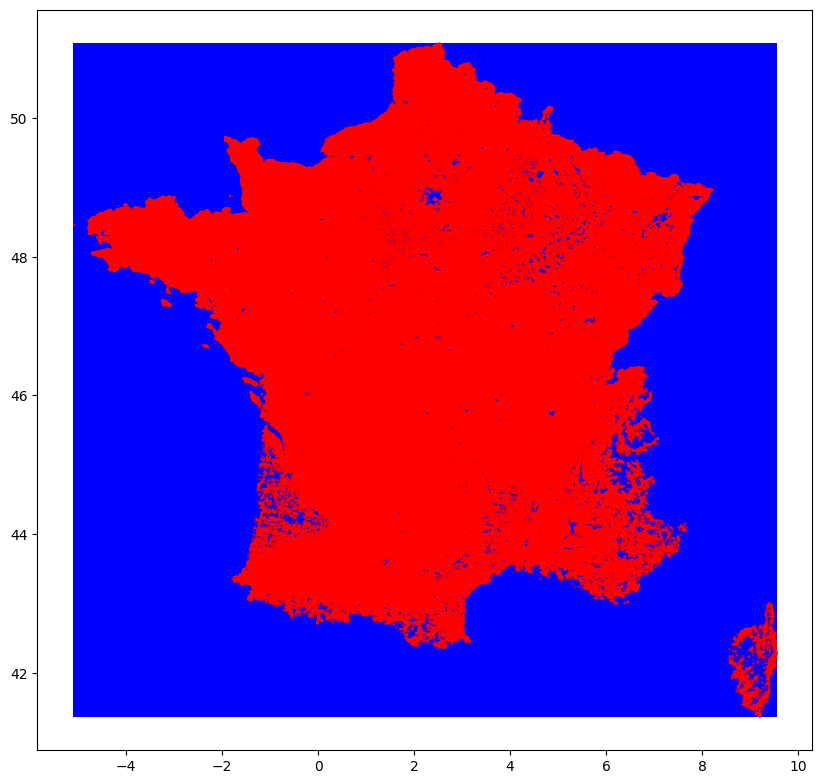

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

patches.plot(ax=ax,color="blue")
gdf.to_crs("EPSG:4326").plot(ax=ax,color="red")
plt.show()

In [ ]:
patches.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
gdf.crs

<Projected CRS: EPSG:2154>
Name: RGF93 v1 / Lambert-93
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: France - onshore and offshore, mainland and Corsica (France métropolitaine including Corsica).
- bounds: (-9.86, 41.15, 10.38, 51.56)
Coordinate Operation:
- name: Lambert-93
- method: Lambert Conic Conformal (2SP)
Datum: Reseau Geodesique Francais 1993 v1
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

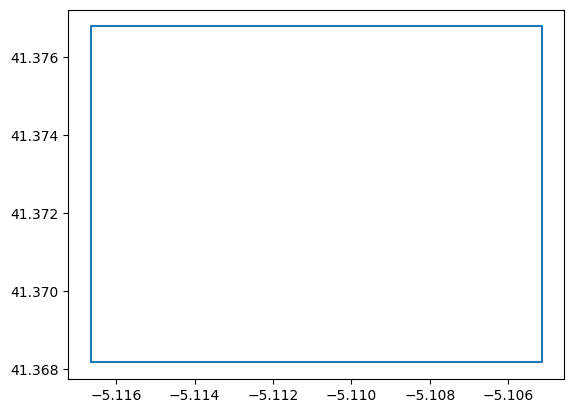

In [16]:
x,y = patches.iloc[0]["geometry"].exterior.xy
plt.plot(x, y)
plt.show()

In [ ]:
patches.to_file(f"../gpkgs/france_patches_{YEAR}.gpkg")

: 